# Import Library


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.svm import SVR
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split


2023-05-22 18:39:38.879656: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-05-22 18:39:38.880975: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-05-22 18:39:38.908387: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-05-22 18:39:38.909017: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-05-22 18:39:39.370560: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not fin

# Data Understanding


In [2]:
df = pd.read_csv(r'DataProduksi.csv')
df

,Tanggal,Minyak Sawit,Karet Kering,Teh
0,Jan-09,1427.10,50.00,8.80
1,Feb-09,1188.00,45.50,7.90
2,Mar-09,1346.70,40.10,8.50
3,Apr-09,1193.50,38.80,9.30
4,May-09,1239.50,47.20,10.30
...,...,...,...,...
115,Aug-18,2075.95,35.32,5.99
116,Sep-18,2093.69,49.37,6.78
117,Oct-18,2075.70,51.21,8.12
118,Nov-18,1931.94,48.77,8.48


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Tanggal       120 non-null    object 
 1   Minyak Sawit  120 non-null    float64
 2   Karet Kering  120 non-null    float64
 3   Teh           120 non-null    float64
dtypes: float64(3), object(1)
memory usage: 3.9+ KB


# Preprocessing


## Change date format


In [4]:
df['Tanggal'] = pd.to_datetime(
    df['Tanggal'], format='%b-%y').dt.strftime('%Y-%m')
df.head()

,Tanggal,Minyak Sawit,Karet Kering,Teh
0,2009-01,1427.1,50.0,8.8
1,2009-02,1188.0,45.5,7.9
2,2009-03,1346.7,40.1,8.5
3,2009-04,1193.5,38.8,9.3
4,2009-05,1239.5,47.2,10.3


## Separating DataFrame Columns into Separate Variables


In [5]:
dates = df['Tanggal'].values
minyak_sawit = df['Minyak Sawit'].values
karet_kering = df['Karet Kering'].values
teh = df['Teh'].values

## Split Dataset


In [6]:
def split_data(X, y, split_percentage):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=split_percentage, shuffle=False)
    return X_train, X_test, y_train, y_test

## Normalization


In [7]:
scaler = MinMaxScaler()
def normalization(data):
    return scaler.fit_transform(data.reshape(-1, 1))


def to_original_value(data):
    return scaler.inverse_transform(data.reshape(-1, 1))

# Generate Output


## Generate R2 Score


In [8]:
def generate_r2(y_test, y_pred):
    r2 = r2_score(y_test,y_pred)
    print("R2 score: {:.2%}".format(r2))

## Generate Plot

In [9]:
def generate_plot(X_data, y_data, X_name, y_name, attribute_name):
    plt.figure(figsize=(10, 6))
    plt.plot(X_data, label=X_name)
    plt.plot(y_data, label=y_name)
    plt.title(f'{X_name} vs {y_name} {attribute_name}')
    plt.xlabel('Bulan')
    plt.ylabel('Nilai Produksi')
    plt.legend()
    plt.show()
    print('\n')

## Generate LSTM Prediction

In [10]:
def predict_lstm(model, data, num_features, num_months):
    data_norm = normalization(data)
    input_seq = data_norm[-num_features:]
    future_preds_norm = []
    for i in range(num_months):
        pred_norm = model.predict(input_seq.reshape(1, -1))
        future_preds_norm.append(pred_norm[0])
        input_seq = np.append(input_seq[1:], pred_norm)
    future_preds = to_original_value(np.array(future_preds_norm))
    return future_preds


## Generate SVR Prediction  

In [11]:
def predict_future_svr(model, data, num_features, num_months):
    data_norm = normalization(data)
    input_seq = data_norm[-num_features:]
    future_preds_norm = []
    for i in range(num_months):
        pred_norm = model.predict(input_seq.reshape(1, -1))
        future_preds_norm.append(pred_norm[0])
        input_seq = np.append(input_seq[1:], pred_norm)
    return to_original_value(np.array(future_preds_norm))

# LSTM model


In [12]:
def model_lstm(data, attribute_name, split_percentage=0.2, epochs=50, activation='relu'):
    X_train, X_test, y_train, y_test = split_data(normalization(data), normalization(data), split_percentage)

    model = Sequential([
        LSTM(60, return_sequences=True),
        Dropout(0.1),
        LSTM(60, return_sequences=True),
        Dropout(0.1),
        LSTM(60),
        Dropout(0.1),
        Dense(30, activation),
        Dense(10, activation),
        Dense(1)
    ])
    model.compile(loss="mae", optimizer=Adam() , metrics=["mae"])
    model.fit(tf.expand_dims(X_train, axis=-1), tf.expand_dims(y_train, axis=-1), epochs=epochs, verbose=2)


    y_pred = model.predict(X_test)
    train_pred = model.predict(X_train)

    generate_r2(y_test, y_pred)

    generate_plot(to_original_value(y_test), to_original_value(y_pred), 'Data Test', 'Data Prediksi', attribute_name)
    generate_plot(to_original_value(X_train), to_original_value(train_pred), 'Data Training','Data Prediksi', attribute_name)
    
    num_features = 12
    num_months = 6 
    future_preds = predict_lstm(model, data, num_features, num_months)


    num_months = [2, 5, 7, 8]
    for n in num_months:
        future_preds = predict_future_svr(model, minyak_sawit, 1, n)
        print(f"Prediksi {n} bulan ke depan: {future_preds}")

# LSTM Evaluation


## Minyak Sawit


Epoch 1/1000


2023-05-22 18:39:40.544539: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-05-22 18:39:40.545189: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-05-22 18:39:40.546122: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

3/3 - 3s - loss: 0.3945 - mae: 0.3945 - 3s/epoch - 980ms/step
Epoch 2/1000
3/3 - 0s - loss: 0.3465 - mae: 0.3465 - 10ms/epoch - 3ms/step
Epoch 3/1000
3/3 - 0s - loss: 0.2961 - mae: 0.2961 - 19ms/epoch - 6ms/step
Epoch 4/1000
3/3 - 0s - loss: 0.2411 - mae: 0.2411 - 12ms/epoch - 4ms/step
Epoch 5/1000
3/3 - 0s - loss: 0.1924 - mae: 0.1924 - 16ms/epoch - 5ms/step
Epoch 6/1000
3/3 - 0s - loss: 0.1516 - mae: 0.1516 - 21ms/epoch - 7ms/step
Epoch 7/1000
3/3 - 0s - loss: 0.1494 - mae: 0.1494 - 25ms/epoch - 8ms/step
Epoch 8/1000
3/3 - 0s - loss: 0.1582 - mae: 0.1582 - 19ms/epoch - 6ms/step
Epoch 9/1000
3/3 - 0s - loss: 0.1590 - mae: 0.1590 - 20ms/epoch - 7ms/step
Epoch 10/1000
3/3 - 0s - loss: 0.1528 - mae: 0.1528 - 18ms/epoch - 6ms/step
Epoch 11/1000
3/3 - 0s - loss: 0.1433 - mae: 0.1433 - 18ms/epoch - 6ms/step
Epoch 12/1000
3/3 - 0s - loss: 0.1383 - mae: 0.1383 - 20ms/epoch - 7ms/step
Epoch 13/1000
3/3 - 0s - loss: 0.1390 - mae: 0.1390 - 19ms/epoch - 6ms/step
Epoch 14/1000
3/3 - 0s - loss: 0.1

2023-05-22 18:39:58.003982: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-05-22 18:39:58.004807: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-05-22 18:39:58.005545: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

3/3 [==============================] - 0s 2ms/step
R2 score: 99.57%


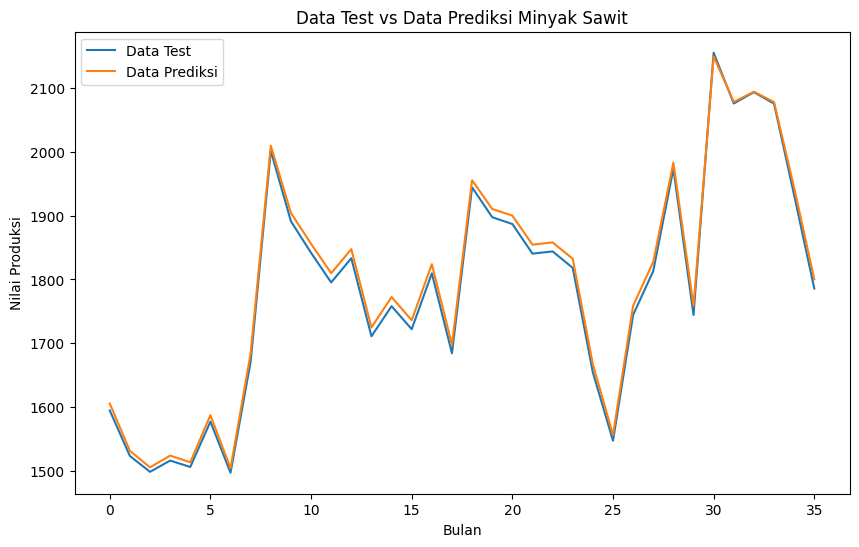

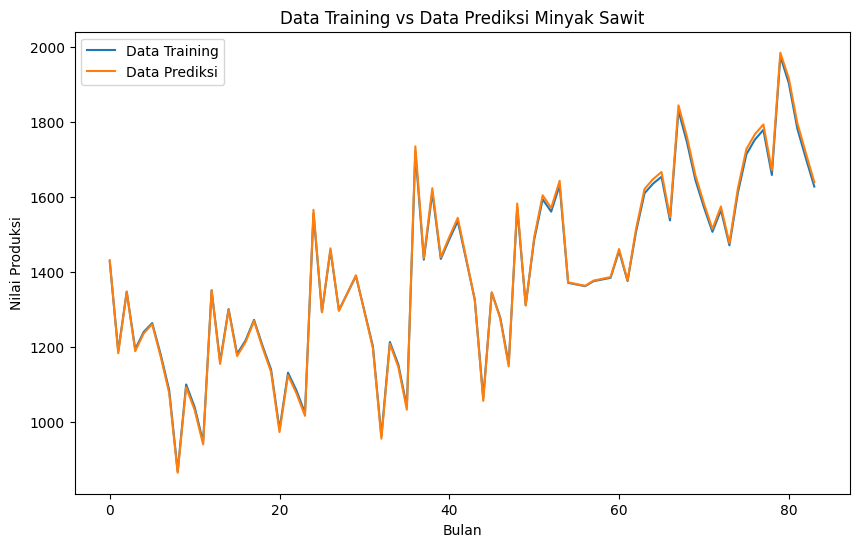

2023-05-22 18:39:58.870800: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-05-22 18:39:58.871840: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-05-22 18:39:58.872434: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

1/1 [==============================] - 0s 15ms/step
Prediksi 2 bulan ke depan: [[1800.192 ]
 [1814.6497]]
1/1 [==============================] - 0s 14ms/step
Prediksi 5 bulan ke depan: [[1800.192 ]
 [1814.6497]
 [1829.0319]
 [1843.2863]
 [1857.3608]]
1/1 [==============================] - 0s 13ms/step
Prediksi 7 bulan ke depan: [[1800.192 ]
 [1814.6497]
 [1829.0319]
 [1843.2863]
 [1857.3608]
 [1871.2045]
 [1884.7675]]
1/1 [==============================] - 0s 13ms/step
Prediksi 8 bulan ke depan: [[1800.192 ]
 [1814.6497]
 [1829.0319]
 [1843.2863]
 [1857.3608]
 [1871.2045]
 [1884.7675]
 [1898.003 ]]


In [13]:
model_lstm(minyak_sawit, 'Minyak Sawit', 0.3, 1000, 'tanh')

## Karet Kering


Epoch 1/1000


2023-05-22 18:40:00.610281: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-05-22 18:40:00.611292: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-05-22 18:40:00.614149: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

3/3 - 3s - loss: 1.3828 - mae: 1.3828 - 3s/epoch - 916ms/step
Epoch 2/1000
3/3 - 0s - loss: 1.3092 - mae: 1.3092 - 14ms/epoch - 5ms/step
Epoch 3/1000
3/3 - 0s - loss: 1.2359 - mae: 1.2359 - 20ms/epoch - 7ms/step
Epoch 4/1000
3/3 - 0s - loss: 1.1629 - mae: 1.1629 - 10ms/epoch - 3ms/step
Epoch 5/1000
3/3 - 0s - loss: 1.0901 - mae: 1.0901 - 9ms/epoch - 3ms/step
Epoch 6/1000
3/3 - 0s - loss: 1.0174 - mae: 1.0174 - 9ms/epoch - 3ms/step
Epoch 7/1000
3/3 - 0s - loss: 0.9451 - mae: 0.9451 - 9ms/epoch - 3ms/step
Epoch 8/1000
3/3 - 0s - loss: 0.8724 - mae: 0.8724 - 9ms/epoch - 3ms/step
Epoch 9/1000
3/3 - 0s - loss: 0.7999 - mae: 0.7999 - 9ms/epoch - 3ms/step
Epoch 10/1000
3/3 - 0s - loss: 0.7265 - mae: 0.7265 - 9ms/epoch - 3ms/step
Epoch 11/1000
3/3 - 0s - loss: 0.6530 - mae: 0.6530 - 9ms/epoch - 3ms/step
Epoch 12/1000
3/3 - 0s - loss: 0.5783 - mae: 0.5783 - 8ms/epoch - 3ms/step
Epoch 13/1000
3/3 - 0s - loss: 0.5038 - mae: 0.5038 - 9ms/epoch - 3ms/step
Epoch 14/1000
3/3 - 0s - loss: 0.4350 - mae

2023-05-22 18:40:14.103976: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-05-22 18:40:14.104954: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-05-22 18:40:14.105496: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

3/3 [==============================] - 0s 11ms/step
R2 score: 99.72%


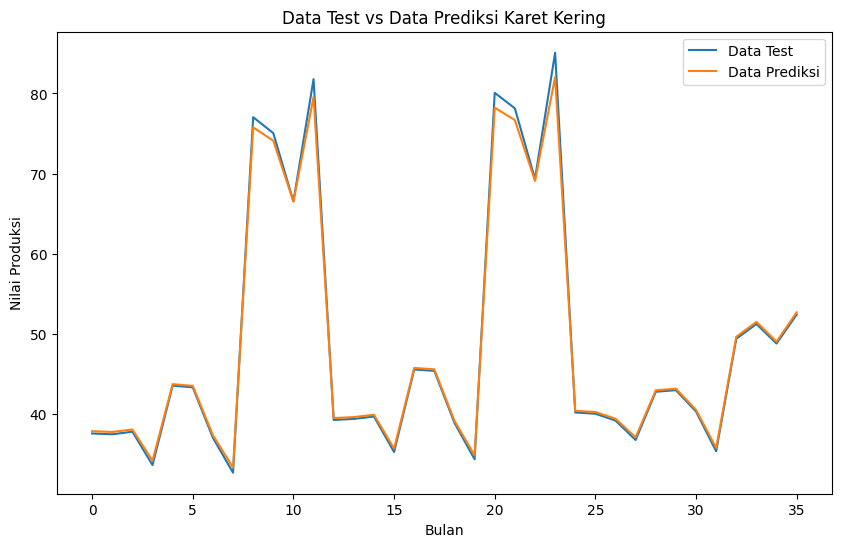

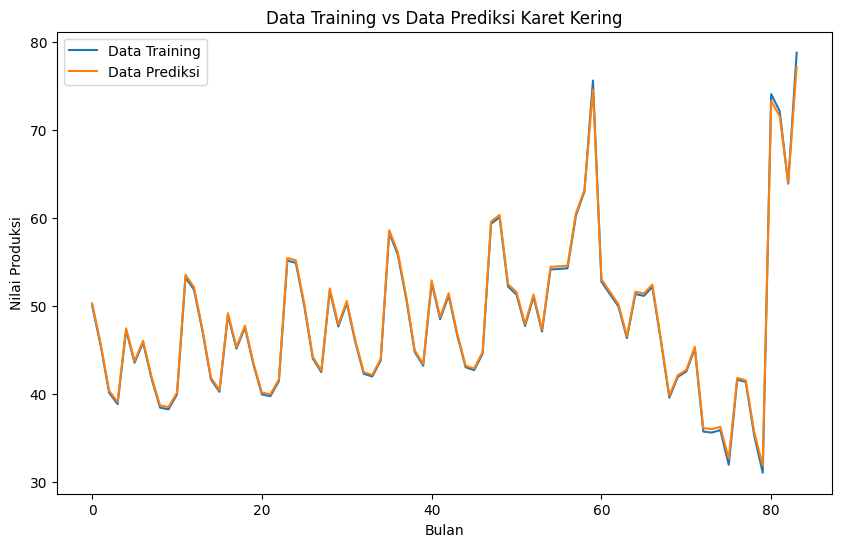

2023-05-22 18:40:14.865241: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-05-22 18:40:14.866080: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-05-22 18:40:14.866709: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

1/1 [==============================] - 1s 672ms/step


2023-05-22 18:40:15.256074: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_1_grad/concat/split_1/split_dim' with dtype int32
	 [[{{node gradients/split_1_grad/concat/split_1/split_dim}}]]


1/1 [==============================] - 0s 11ms/step
Prediksi 2 bulan ke depan: [[1779.1254]
 [1773.1663]]
1/1 [==============================] - 0s 11ms/step
Prediksi 5 bulan ke depan: [[1779.1254]
 [1773.1663]
 [1767.7584]
 [1762.839 ]
 [1758.3545]]
1/1 [==============================] - 0s 13ms/step
Prediksi 7 bulan ke depan: [[1779.1254]
 [1773.1663]
 [1767.7584]
 [1762.839 ]
 [1758.3545]
 [1754.258 ]
 [1750.5093]]
1/1 [==============================] - 0s 11ms/step
Prediksi 8 bulan ke depan: [[1779.1254]
 [1773.1663]
 [1767.7584]
 [1762.839 ]
 [1758.3545]
 [1754.258 ]
 [1750.5093]
 [1747.0736]]


In [14]:
model_lstm(karet_kering, 'Karet Kering', 0.3, 1000, 'sigmoid')


## Teh


Epoch 1/1000


2023-05-22 18:40:16.356948: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-05-22 18:40:16.357579: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-05-22 18:40:16.358324: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

3/3 - 3s - loss: 0.6236 - mae: 0.6236 - 3s/epoch - 925ms/step
Epoch 2/1000
3/3 - 0s - loss: 0.5766 - mae: 0.5766 - 9ms/epoch - 3ms/step
Epoch 3/1000
3/3 - 0s - loss: 0.5295 - mae: 0.5295 - 11ms/epoch - 4ms/step
Epoch 4/1000
3/3 - 0s - loss: 0.4827 - mae: 0.4827 - 14ms/epoch - 5ms/step
Epoch 5/1000
3/3 - 0s - loss: 0.4363 - mae: 0.4363 - 9ms/epoch - 3ms/step
Epoch 6/1000
3/3 - 0s - loss: 0.3903 - mae: 0.3903 - 9ms/epoch - 3ms/step
Epoch 7/1000
3/3 - 0s - loss: 0.3489 - mae: 0.3489 - 9ms/epoch - 3ms/step
Epoch 8/1000
3/3 - 0s - loss: 0.3134 - mae: 0.3134 - 9ms/epoch - 3ms/step
Epoch 9/1000
3/3 - 0s - loss: 0.2784 - mae: 0.2784 - 9ms/epoch - 3ms/step
Epoch 10/1000
3/3 - 0s - loss: 0.2498 - mae: 0.2498 - 9ms/epoch - 3ms/step
Epoch 11/1000
3/3 - 0s - loss: 0.2216 - mae: 0.2216 - 8ms/epoch - 3ms/step
Epoch 12/1000
3/3 - 0s - loss: 0.1964 - mae: 0.1964 - 9ms/epoch - 3ms/step
Epoch 13/1000
3/3 - 0s - loss: 0.1771 - mae: 0.1771 - 9ms/epoch - 3ms/step
Epoch 14/1000
3/3 - 0s - loss: 0.1669 - mae:

2023-05-22 18:40:30.062226: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-05-22 18:40:30.063127: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-05-22 18:40:30.063745: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

3/3 [==============================] - 0s 1ms/step
R2 score: 99.96%


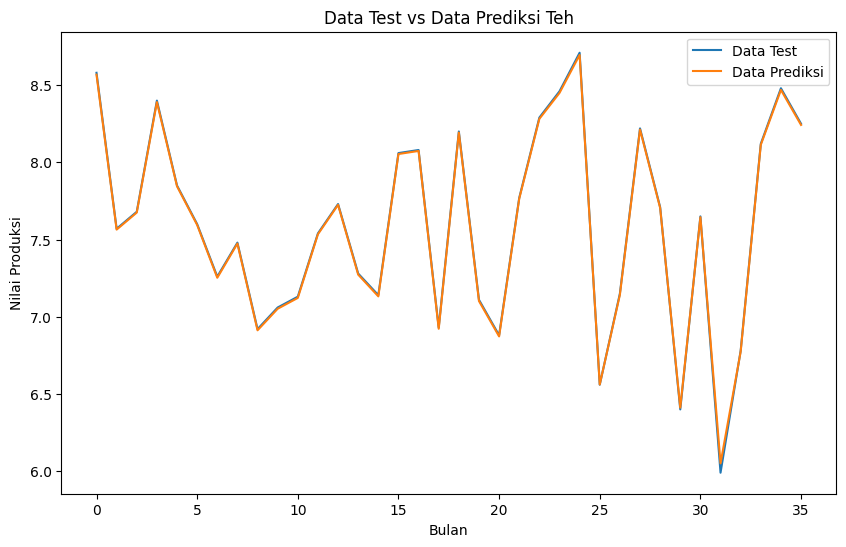

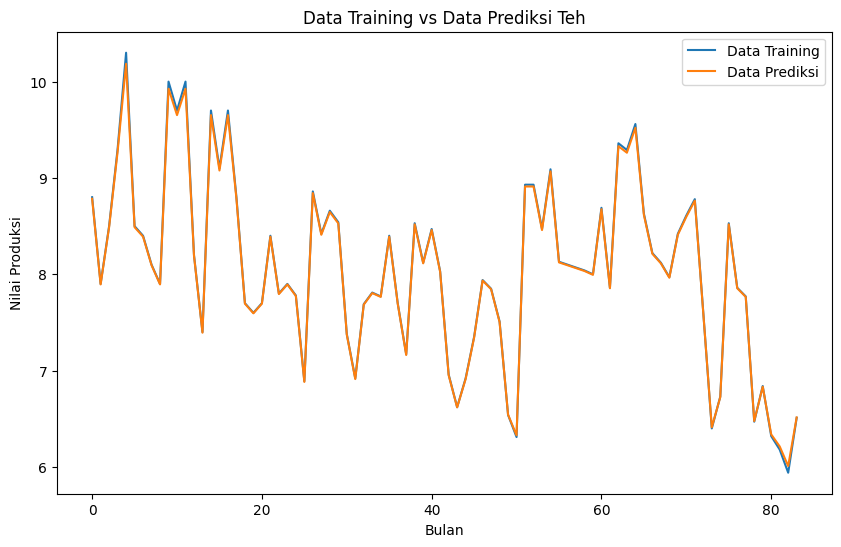

2023-05-22 18:40:30.753591: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-05-22 18:40:30.754242: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-05-22 18:40:30.754893: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

1/1 [==============================] - 0s 11ms/step
Prediksi 2 bulan ke depan: [[1779.4169]
 [1773.2716]]
1/1 [==============================] - 0s 11ms/step
Prediksi 5 bulan ke depan: [[1779.4169]
 [1773.2716]
 [1767.2675]
 [1761.3982]
 [1755.6578]]
1/1 [==============================] - 0s 11ms/step
Prediksi 7 bulan ke depan: [[1779.4169]
 [1773.2716]
 [1767.2675]
 [1761.3982]
 [1755.6578]
 [1750.0414]
 [1744.5437]]
1/1 [==============================] - 0s 12ms/step
Prediksi 8 bulan ke depan: [[1779.4169]
 [1773.2716]
 [1767.2675]
 [1761.3982]
 [1755.6578]
 [1750.0414]
 [1744.5437]
 [1739.1604]]


In [15]:
model_lstm(teh, 'Teh', 0.3, 1000, 'sigmoid')


# SVR Model


In [16]:
def model_svr(data, attribute_name, split_percentage=0.2, c=1000, gamma='scale', epsilon=0.1):
    X_train, X_test, y_train, y_test = split_data(normalization(data), normalization(data), split_percentage)


    model = SVR(kernel='rbf', C=c, gamma=gamma, epsilon=epsilon)
    model.fit(X_train.reshape(-1,1), y_train.ravel())
    

    y_pred = model.predict(X_test)
    train_pred = model.predict(X_train.reshape(-1,1))

    generate_r2(y_test, y_pred)

    generate_plot(to_original_value(y_test), to_original_value(y_pred), 'Data Test', 'Data Prediksi', attribute_name)
    generate_plot(to_original_value(X_train), to_original_value(train_pred), 'Data Training','Data Prediksi', attribute_name)

    num_months = [2, 5, 7, 8]
    for n in num_months:
        future_preds = predict_future_svr(model, minyak_sawit, 1, n)
        print(f"Prediksi {n} bulan ke depan: {future_preds}")

# SVR Evaluation


## Minyak Sawit


R2 score: 99.73%


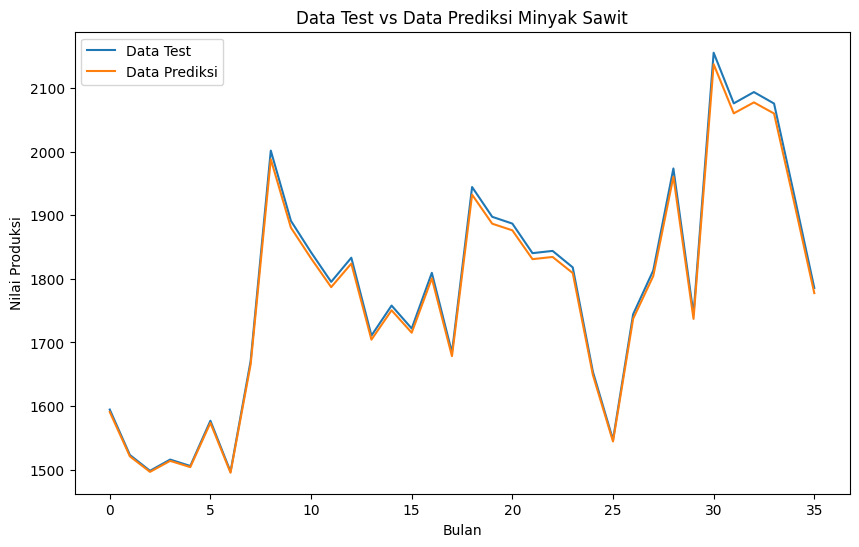

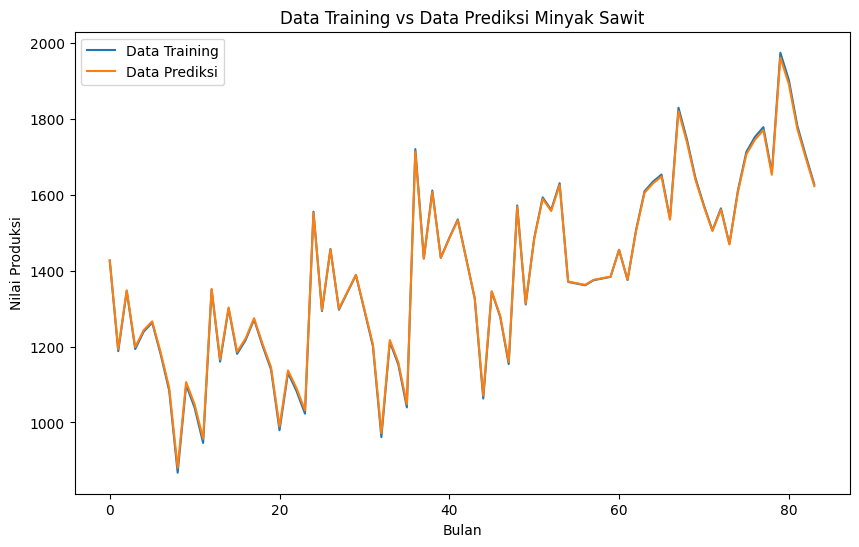



Prediksi 2 bulan ke depan: [[1777.6059426 ]
 [1769.69431103]]
Prediksi 5 bulan ke depan: [[1777.6059426 ]
 [1769.69431103]
 [1761.9697393 ]
 [1754.42706176]
 [1747.06130267]]
Prediksi 7 bulan ke depan: [[1777.6059426 ]
 [1769.69431103]
 [1761.9697393 ]
 [1754.42706176]
 [1747.06130267]
 [1739.86766642]
 [1732.84152842]]
Prediksi 8 bulan ke depan: [[1777.6059426 ]
 [1769.69431103]
 [1761.9697393 ]
 [1754.42706176]
 [1747.06130267]
 [1739.86766642]
 [1732.84152842]
 [1725.97842661]]


In [17]:
model_svr(minyak_sawit, 'Minyak Sawit', 0.3, 100, .01, .01)

## Karet Kering


R2 score: 99.96%


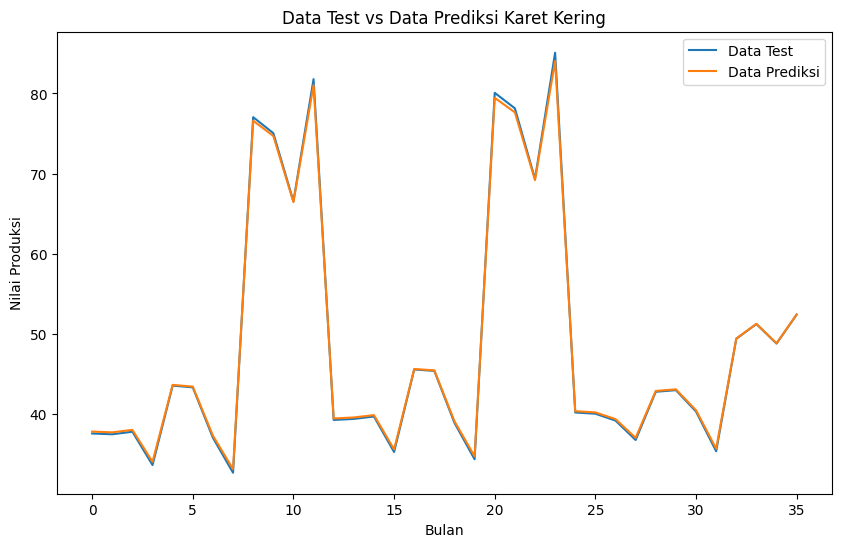

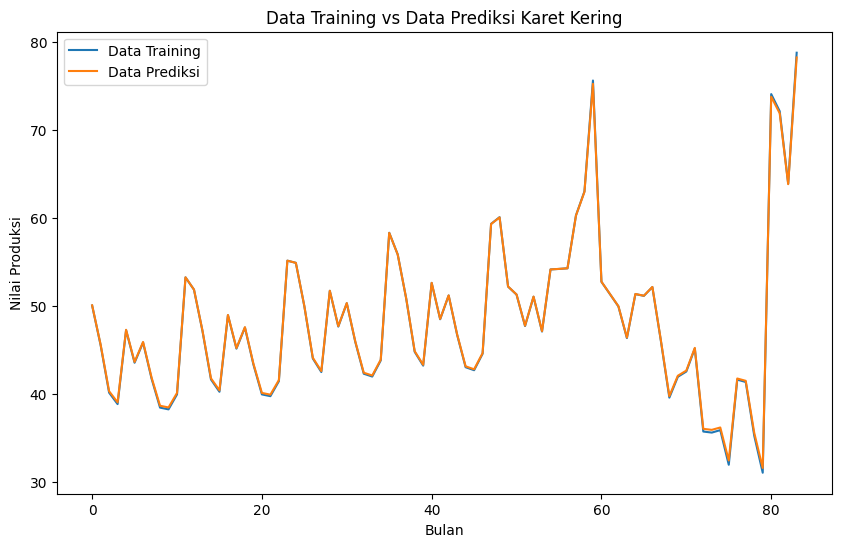



Prediksi 2 bulan ke depan: [[1781.88181444]
 [1778.14977455]]
Prediksi 5 bulan ke depan: [[1781.88181444]
 [1778.14977455]
 [1774.50974975]
 [1770.95785661]
 [1767.49044014]]
Prediksi 7 bulan ke depan: [[1781.88181444]
 [1778.14977455]
 [1774.50974975]
 [1770.95785661]
 [1767.49044014]
 [1764.10405667]
 [1760.7954584 ]]
Prediksi 8 bulan ke depan: [[1781.88181444]
 [1778.14977455]
 [1774.50974975]
 [1770.95785661]
 [1767.49044014]
 [1764.10405667]
 [1760.7954584 ]
 [1757.56157916]]


In [18]:
model_svr(karet_kering, 'Karet Kering', 0.3, 100, .1, .01)

## Teh


R2 score: 99.77%


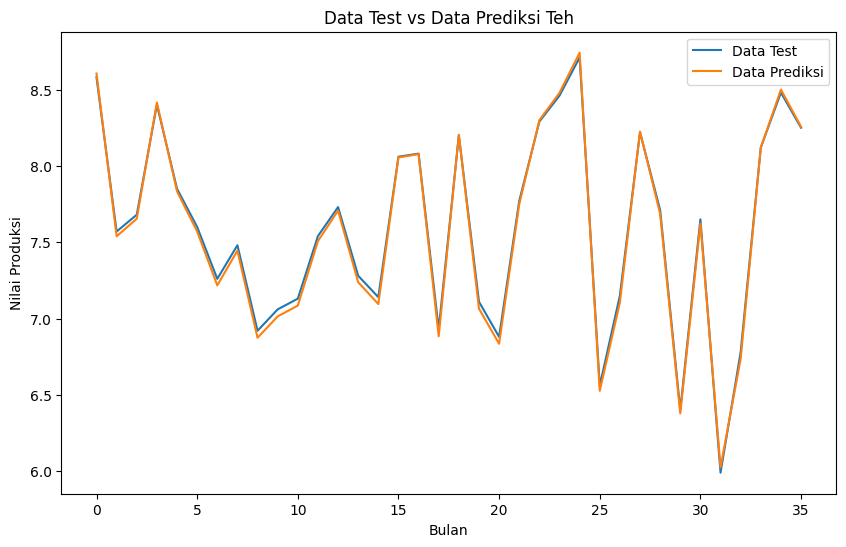

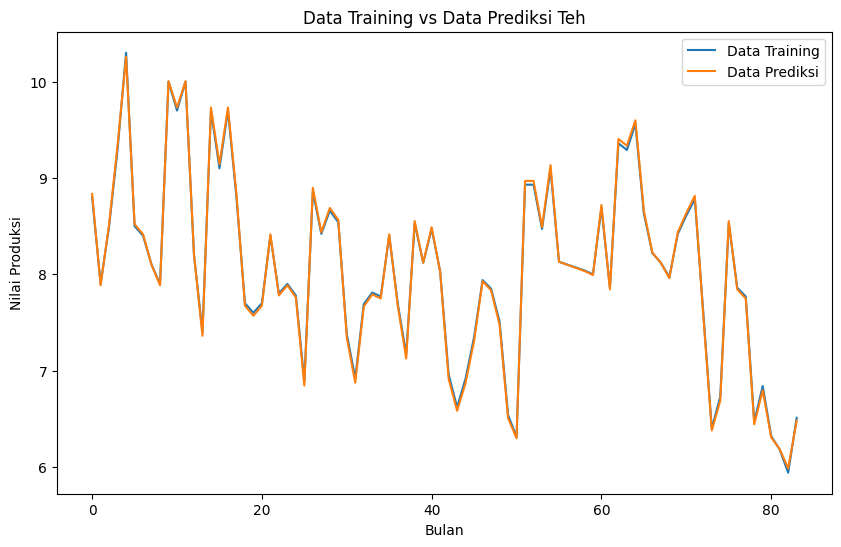



Prediksi 2 bulan ke depan: [[1798.22374616]
 [1810.97033388]]
Prediksi 5 bulan ke depan: [[1798.22374616]
 [1810.97033388]
 [1823.90338897]
 [1836.97056744]
 [1850.11399547]]
Prediksi 7 bulan ke depan: [[1798.22374616]
 [1810.97033388]
 [1823.90338897]
 [1836.97056744]
 [1850.11399547]
 [1863.27097103]
 [1876.37493711]]
Prediksi 8 bulan ke depan: [[1798.22374616]
 [1810.97033388]
 [1823.90338897]
 [1836.97056744]
 [1850.11399547]
 [1863.27097103]
 [1876.37493711]
 [1889.35671892]]


In [19]:
model_svr(teh, 'Teh', 0.3, 100, 1, .01)